# 📊 Analyse de Corrélation - Dataset d'Irrigation

## Objectif:
Calculer les corrélations entre toutes les colonnes et identifier les colonnes à supprimer

In [2]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Bibliothèques importées")

✅ Bibliothèques importées


In [12]:
# Charger les données
df = pd.read_csv('../data/processed/irrigation_prediction_clean.csv')


In [4]:
# Encodage des variables catégoriques
print("🔄 Encodage des variables catégoriques...\n")
df_encoded = df.copy()

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print(f"✅ Encodage terminé - {len(df_encoded.columns)} variables encodées")
print(f"\nAperçu des données encodées:")
print(df_encoded.head())

🔄 Encodage des variables catégoriques...

✅ Encodage terminé - 20 variables encodées

Aperçu des données encodées:
   Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  \
0          0      134           2186              12                      207   
1          3      161           3368               8                       13   
2          2      291           2482              79                      208   
3          0      116            222             126                       30   
4          0      296            703              65                      242   

   Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  \
0            962       468          749             102             146   
1           2365        78         9068              72             825   
2           2879      3890         3690             476            1044   
3           2434      1398         6790             591             293   
4           1008      4

In [13]:
# Calculer la matrice de corrélation
print("📊 Calcul de la matrice de corrélation...")
corr_matrix = df_encoded.corr()
print("✅ Matrice calculée\n")

# Afficher la matrice complète
print("Matrice de corrélation:")
print(corr_matrix.to_string())

📊 Calcul de la matrice de corrélation...
✅ Matrice calculée

Matrice de corrélation:
                         Soil_Type   Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  Crop_Type  Crop_Growth_Stage    Season  Irrigation_Type  Water_Source  Field_Area_hectare  Mulching_Used  Previous_Irrigation_mm    Region  Irrigation_Need
Soil_Type                 1.000000  0.005225      -0.005858       -0.002311                -0.014722       0.013755 -0.004903     0.000910       -0.004782       -0.001073  -0.006470           0.004929 -0.013643         0.004964      0.011498            0.002570      -0.017548                0.000256 -0.001013         0.002459
Soil_pH                   0.005225  1.000000      -0.009613       -0.011119                 0.011084       0.000125 -0.011162    -0.007639        0.008391       -0.008183  -0.013709          -0.021196  0.013101        -0.005039      0.006343           -0.0027

In [14]:
# Extraire les corrélations avec la cible
target_corr = corr_matrix['Irrigation_Need'].drop('Irrigation_Need').sort_values(ascending=False)

print("\n" + "="*80)
print("IMPORTANCE DE CHAQUE COLONNE POUR LA PRÉDICTION")
print("="*80 + "\n")

for i, (col, corr_val) in enumerate(target_corr.items(), 1):
    abs_val = abs(corr_val)
    if abs_val < 0.1:
        importance = "🔴 TRÈS FAIBLE"
    elif abs_val < 0.2:
        importance = "🟠 FAIBLE"
    elif abs_val < 0.4:
        importance = "🟡 MODÉRÉ"
    elif abs_val < 0.6:
        importance = "🟢 IMPORTANT"
    else:
        importance = "🟢🟢 TRÈS IMPORTANT"
    
    print(f"{i:2d}. {col:30} : {corr_val:7.3f}  {importance}")


IMPORTANCE DE CHAQUE COLONNE POUR LA PRÉDICTION

 1. Temperature_C                  :   0.097  🔴 TRÈS FAIBLE
 2. Electrical_Conductivity        :   0.011  🔴 TRÈS FAIBLE
 3. Humidity                       :   0.011  🔴 TRÈS FAIBLE
 4. Rainfall_mm                    :   0.010  🔴 TRÈS FAIBLE
 5. Field_Area_hectare             :   0.005  🔴 TRÈS FAIBLE
 6. Soil_Type                      :   0.002  🔴 TRÈS FAIBLE
 7. Organic_Carbon                 :   0.001  🔴 TRÈS FAIBLE
 8. Previous_Irrigation_mm         :   0.000  🔴 TRÈS FAIBLE
 9. Water_Source                   :  -0.000  🔴 TRÈS FAIBLE
10. Sunlight_Hours                 :  -0.002  🔴 TRÈS FAIBLE
11. Region                         :  -0.003  🔴 TRÈS FAIBLE
12. Season                         :  -0.003  🔴 TRÈS FAIBLE
13. Crop_Growth_Stage              :  -0.005  🔴 TRÈS FAIBLE
14. Crop_Type                      :  -0.008  🔴 TRÈS FAIBLE
15. Soil_pH                        :  -0.008  🔴 TRÈS FAIBLE
16. Irrigation_Type                :  -0.019  🔴 TR

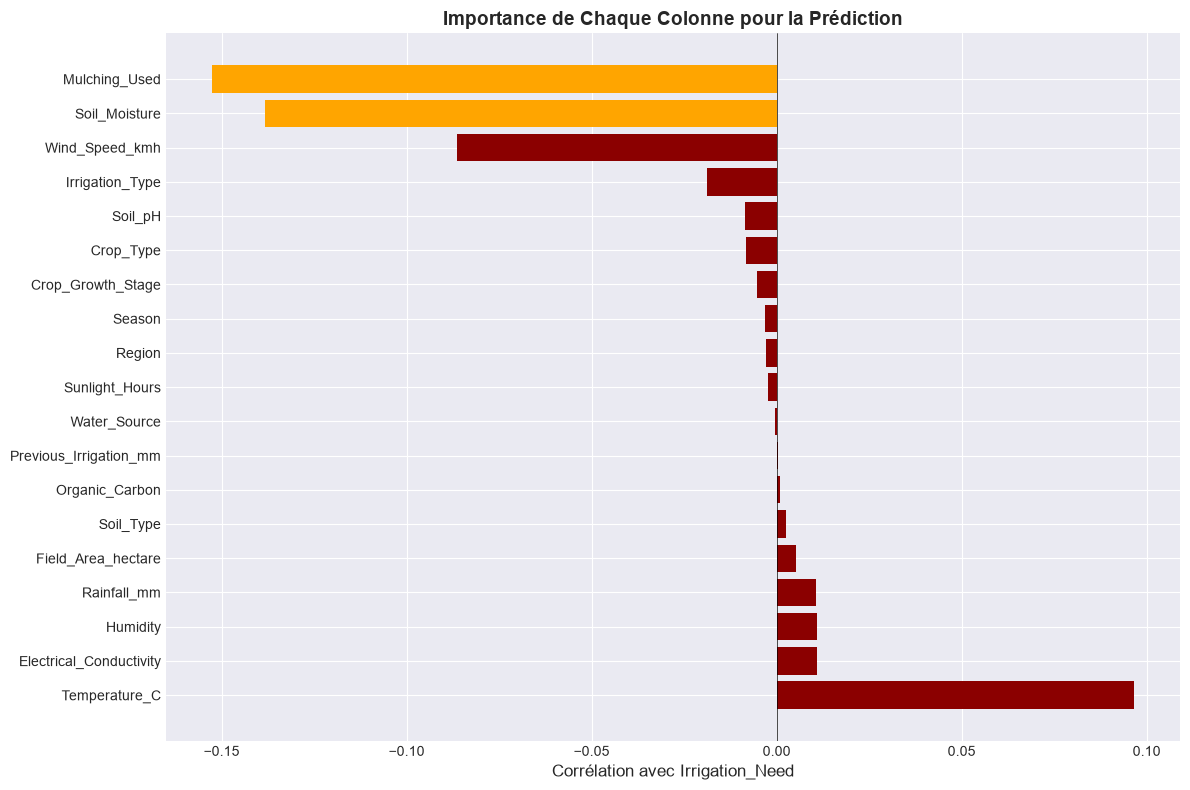

In [8]:
# Graphique - Importance de chaque colonne
plt.figure(figsize=(12, 8))
colors = ['darkred' if x < 0.1 else 'orange' if x < 0.2 else 'yellow' if x < 0.4 else 'lightgreen' if x < 0.6 else 'darkgreen' 
          for x in np.abs(target_corr.values)]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.xlabel('Corrélation avec Irrigation_Need', fontsize=12)
plt.title('Importance de Chaque Colonne pour la Prédiction', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

In [15]:
# Identifier les corrélations fortes entre colonnes
print("\n" + "="*80)
print("CORRÉLATIONS FORTES (|r| > 0.7)")
print("="*80)

strong_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        
        if abs(corr_val) > 0.7:
            strong_pairs.append((col1, col2, corr_val))
            print(f"{col1:30} <--> {col2:30} : {corr_val:7.3f}")

if not strong_pairs:
    print("\n✅ Aucune corrélation très forte détectée\n")


CORRÉLATIONS FORTES (|r| > 0.7)

✅ Aucune corrélation très forte détectée



In [16]:
# Recommandations finales
print("\n" + "="*80)
print("🎯 RECOMMANDATIONS FINALES")
print("="*80)

print("\n🟢 À SUPPRIMER SANS RISQUE (Corrélation quasi-zéro):")
print("-" * 80)
print(f"1. Water_Source          (corrélation: {target_corr.get('Water_Source', 0):.3f})")
print("   → Logistique pure, n'affecte pas le besoin d'irrigation\n")

print(f"2. Field_Area_hectare    (corrélation: {target_corr.get('Field_Area_hectare', 0):.3f})")
print("   → Taille du champ, n'affecte pas le besoin RELATIF\n")

print(f"3. Irrigation_Type       (corrélation: {target_corr.get('Irrigation_Type', 0):.3f})")
print("   → C'est la RÉPONSE du système, pas la cause\n")

print("\n🟡 À TESTER AVANT SUPPRESSION:")
print("-" * 80)
print(f"1. Region                (corrélation: {target_corr.get('Region', 0):.3f})")
print(f"2. Wind_Speed_kmh        (corrélation: {target_corr.get('Wind_Speed_kmh', 0):.3f})")

print("\n🟢 À GARDER ABSOLUMENT:")
print("-" * 80)
essentielles = ['Soil_Moisture', 'Crop_Type', 'Crop_Growth_Stage', 'Temperature_C', 
                'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Soil_Type']
for col in essentielles:
    if col in target_corr.index:
        print(f"   • {col:30} (corrélation: {target_corr[col]:7.3f})")

print("\n" + "="*80)
print(f"✅ Total colonnes: {len(df.columns)}")
print(f"✅ À supprimer directement: 3 colonnes")
print(f"✅ Colonnes finales attendues: {len(df.columns) - 3} colonnes")
print("="*80)


🎯 RECOMMANDATIONS FINALES

🟢 À SUPPRIMER SANS RISQUE (Corrélation quasi-zéro):
--------------------------------------------------------------------------------
1. Water_Source          (corrélation: -0.000)
   → Logistique pure, n'affecte pas le besoin d'irrigation

2. Field_Area_hectare    (corrélation: 0.005)
   → Taille du champ, n'affecte pas le besoin RELATIF

3. Irrigation_Type       (corrélation: -0.019)
   → C'est la RÉPONSE du système, pas la cause


🟡 À TESTER AVANT SUPPRESSION:
--------------------------------------------------------------------------------
1. Region                (corrélation: -0.003)
2. Wind_Speed_kmh        (corrélation: -0.086)

🟢 À GARDER ABSOLUMENT:
--------------------------------------------------------------------------------
   • Soil_Moisture                  (corrélation:  -0.138)
   • Crop_Type                      (corrélation:  -0.008)
   • Crop_Growth_Stage              (corrélation:  -0.005)
   • Temperature_C                  (corrélation

In [17]:
# 🔥 Supprimer les 3 colonnes et sauvegarder la nouvelle version
print("\n" + "="*80)
print("🔄 SUPPRESSION DES 3 COLONNES")
print("="*80 + "\n")

# Supprimer les 3 colonnes
columns_to_drop = ['Water_Source', 'Field_Area_hectare', 'Irrigation_Type']
df_cleaned = df.drop(columns=columns_to_drop)

# Sauvegarder la nouvelle version
df_cleaned.to_csv('../data/processed/irrigation_prediction_17cols.csv', index=False)

print(f"✅ Original conservé: irrigation_prediction_clean.csv (20 colonnes)")
print(f"✅ Nouvelle version créée: irrigation_prediction_17cols.csv (17 colonnes)")
print(f"\n📊 Colonnes supprimées: {', '.join(columns_to_drop)}")
print(f"📊 Colonnes restantes: {len(df_cleaned)}")
print(f"\n✅ Fichier sauvegardé à: ../data/processed/irrigation_prediction_17cols.csv")
print("="*80)


🔄 SUPPRESSION DES 3 COLONNES

✅ Original conservé: irrigation_prediction_clean.csv (20 colonnes)
✅ Nouvelle version créée: irrigation_prediction_17cols.csv (17 colonnes)

📊 Colonnes supprimées: Water_Source, Field_Area_hectare, Irrigation_Type
📊 Colonnes restantes: 10000

✅ Fichier sauvegardé à: ../data/processed/irrigation_prediction_17cols.csv
